In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = "/home/jovyan/work/children15mc"
PROC = f"{BASE}/data/processed"
FIG = f"{BASE}/outputs/figures"

df = gpd.read_file(f"{PROC}/accessibility.gpkg")
print(f"{len(df)} LSOAs")
print(df[["idaci_score", "c15mc_score", "child_pop"]].describe())

4994 LSOAs
       idaci_score  c15mc_score    child_pop
count  4994.000000  4994.000000  4994.000000
mean      0.174673     5.604325   319.560272
std       0.099087     5.308925   105.944442
min       0.004000     0.000000    32.000000
25%       0.092000     2.000000   252.000000
50%       0.166000     4.000000   308.000000
75%       0.248000     7.000000   377.000000
max       0.572000    39.000000   865.000000


/tmp/ipykernel_743/1935431085.py:13: UserWarning: Glyph 26012 (\N{CJK UNIFIED IDEOGRAPH-659C}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{FIG}/scatter_idaci_access.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_743/1935431085.py:13: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{FIG}/scatter_idaci_access.png", dpi=150, bbox_inches="tight")
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26012 (\N{CJK UNIFIED IDEOGRAPH-659C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


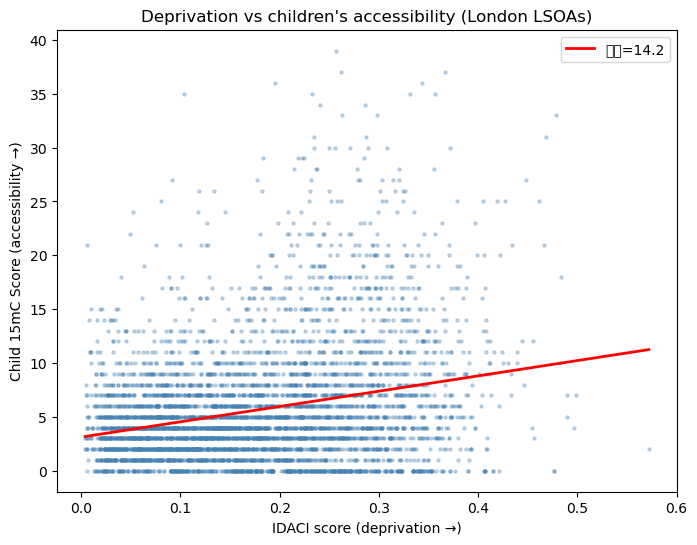

Correlation coefficient: 0.265


In [2]:
# Scatter plot: IDACI vs. Accessibility
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["idaci_score"], df["c15mc_score"], s=5, alpha=0.3, color="steelblue")
ax.set_xlabel("IDACI score (deprivation →)")
ax.set_ylabel("Child 15mC Score (accessibility →)")
ax.set_title("Deprivation vs children's accessibility (London LSOAs)")

# Add a trend line
z = np.polyfit(df["idaci_score"], df["c15mc_score"], 1)
xs = np.linspace(df["idaci_score"].min(), df["idaci_score"].max(), 100)
ax.plot(xs, np.polyval(z, xs), color="red", lw=2, label=f"斜率={z[0]:.1f}")
ax.legend()
plt.savefig(f"{FIG}/scatter_idaci_access.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlation coefficient: {df['idaci_score'].corr(df['c15mc_score']):.3f}")

In [3]:
import statsmodels.api as sm

# Add a control variable: population density (child population / LSOA area)
df["area_km2"] = df.geometry.area / 1e6
df["child_density"] = df["child_pop"] / df["area_km2"]

# Independent variables: IDACI + child density; Dependent variable: accessibility score
X = df[["idaci_score", "child_density"]].copy()
X = sm.add_constant(X)
y = df["c15mc_score"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            c15mc_score   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     242.1
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          4.44e-101
Time:                        00:28:56   Log-Likelihood:                -15191.
No. Observations:                4994   AIC:                         3.039e+04
Df Residuals:                    4991   BIC:                         3.041e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.5655      0.156     16.467

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Check the VIF for each independent variable
X_check = df[["idaci_score", "child_density"]].copy()
X_check = sm.add_constant(X_check)

print("VIF Check")
for i, col in enumerate(X_check.columns):
    vif = variance_inflation_factor(X_check.values, i)
    print(f"{col:15s} VIF = {vif:.2f}")

VIF Check
const           VIF = 4.72
idaci_score     VIF = 1.18
child_density   VIF = 1.18


In [5]:
from sklearn.preprocessing import StandardScaler

# Standardize the two independent variables
scaler = StandardScaler()
df[["idaci_z", "child_density_z"]] = scaler.fit_transform(
    df[["idaci_score", "child_density"]])

# Rerun using standardized variables
X = df[["idaci_z", "child_density_z"]]
X = sm.add_constant(X)
y = df["c15mc_score"]

model_z = sm.OLS(y, X).fit()
print(model_z.summary())

                            OLS Regression Results                            
Dep. Variable:            c15mc_score   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     242.1
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          4.44e-101
Time:                        00:28:58   Log-Likelihood:                -15191.
No. Observations:                4994   AIC:                         3.039e+04
Df Residuals:                    4991   BIC:                         3.041e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               5.6043      0.072     

In [6]:
import numpy as np

# log-transform the dependent variable
df["c15mc_log"] = np.log(df["c15mc_score"] + 1)

from scipy.stats import skew
print("Skewness Before transformation:", round(skew(df["c15mc_score"]), 2))
print("Skewness after transformation:", round(skew(df["c15mc_log"]), 2))

# Rerun OLS using the log of the dependent variable
X = df[["idaci_z", "child_density_z"]]
X = sm.add_constant(X)
y_log = df["c15mc_log"]

model_log = sm.OLS(y_log, X).fit()
print(model_log.summary())

Skewness Before transformation: 1.98
Skewness after transformation: -0.3
                            OLS Regression Results                            
Dep. Variable:              c15mc_log   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     113.6
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           5.74e-49
Time:                        00:29:00   Log-Likelihood:                -5876.8
No. Observations:                4994   AIC:                         1.176e+04
Df Residuals:                    4991   BIC:                         1.178e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

In [7]:
from libpysal.weights import Queen
from esda.moran import Moran
import numpy as np

#1.Constructing a spatial weight matrix
w = Queen.from_dataframe(df, use_index=False)
w.transform = "r"
print(f"Average neighbors per LSOA: {w.mean_neighbors:.1f}")

#2.Calculate Moran's I for accessibility scores
moran = Moran(df["c15mc_log"].values, w)
print(f"\n=== Moran's I(accessibility scores) ===")
print(f"Moran's I = {moran.I:.3f}")
print(f"p-value   = {moran.p_sim:.4f}")

#3.Calculate Moran's I for OLS residuals
df["ols_resid"] = model_log.resid
moran_resid = Moran(df["ols_resid"].values, w)
print(f"\n=== Moran's I(OLS residuals) ===")
print(f"Moran's I = {moran_resid.I:.3f}")
print(f"p-value   = {moran_resid.p_sim:.4f}")

ModuleNotFoundError: No module named 'esda'